## PCA ANALYSIS FOR PEX-A HOTSPOT

In [2]:
from re import search, compile
from spectrum_preprocessing import pipeline, distribution_Selection
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.optimize import curve_fit
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import pickle as pk
import numpy as np
import os

numlike = compile(r"^-?\d+(\.\d+)?$")

Functions

In [3]:
def roundWavenumbers(dataframe):
    """
    Function for rounding the wavenumbers so that there is no mismatch between the machine 
    precision of saving the files in Quasar and the wavenumbers output by the FTIR microscope
    """
    numlike = compile(r"^-?\d+(\.\d+)?$")
    numeric_idxs = np.array([c for c in dataframe.columns if numlike.match(str(c).strip())])

    dataframe = dataframe.rename(columns=lambda c: round(float(c), 1) if c in numeric_idxs else c)
    return dataframe

def IR_PCA(input_data, PCs):

    scaler = StandardScaler()
    input_data_scaled = scaler.fit_transform(input_data)
    
    pca = PCA(n_components = PCs)
    data_PCs = pca.fit_transform(input_data_scaled)
    columns_list = ['PC'+ str(x) for x in range(1, PCs+1)]
    PC_df = pd.DataFrame(data = data_PCs,
                                columns = columns_list)
    
    feature_weights = pca.components_
    loadings_df = pd.DataFrame(feature_weights)
    
    print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))
    
    return(PC_df, loadings_df)

Import and Format Data

In [5]:
if not os.path.exists("C:/Users/Zach/Documents/GitHub/Feature Extraction/KMeans_Feature_Extraction/training_data.csv"):
        filepath = 'C:/Users/Zach/Documents/GitHub/betaVAE_Training/training_data/'

        #file2 = 'SMP65 010 0-100d Hotspot Spectra 800um.csv'
        allFiles = os.listdir(filepath)
        # Take only the files that contain data pertaining to SMP65#010 
        trainingFiles = [file for file in allFiles if file.endswith('.csv') and 'SMP65#010' in file and 'full width' not in file and 'hotspot' not in file]

        trainingFiles = sorted(trainingFiles, key=lambda x: int(search(r'(?<= )(.+?)(?=d)', x).group()))

        print(trainingFiles)
        # Read all of the data and place the dataframes into a list
        trainingDataframeList = [pd.read_csv(filepath+file, low_memory=True, skiprows=[1,2]) for file in trainingFiles]

        masked_trainingDataframeList = []

        for df in trainingDataframeList:
                _, _, mask_selected, modePosition, areaPE = distribution_Selection(df, '1981.7 - 2095.8', 4)
                df[mask_selected] = df[mask_selected].ffill()
                masked_trainingDataframeList.append(df[mask_selected])
        trainingDataframeList = None # Clear memory

        rawTrainingDataframe = pd.concat(
        (
            df.rename(
                columns=lambda c: round(float(c), 1) if numlike.match(str(c).strip()) else c
            )
            for df in masked_trainingDataframeList
        ),
        ignore_index=True
        )

        training_df = pd.concat(masked_trainingDataframeList, ignore_index=True)
        training_df = roundWavenumbers(training_df)
        masked_trainingDataframeList = None # Clear memory of list of dataframes since we have one dataframe now

        numlike = compile(r"^-?\d+(\.\d+)?$")

        wavenumbers = np.array([c for c in training_df.columns if numlike.match(str(c).strip())])

        interpDataFramelist = []
        for index, full_row in training_df.iterrows():

                spectra = full_row[wavenumbers]
                metas = full_row.drop(wavenumbers)
                meta_cols = metas.index
                meta_values = metas.to_numpy()

                frequencies = spectra.index.to_numpy(dtype=float)
                frequencies = frequencies[::-1]  # Reverse the order for interpolation

                spectrum = spectra.to_numpy(dtype=float)
                spectrum = spectrum[::-1]  # Reverse the order for interpolation

                frequencies, spectrum = pipeline(frequencies, spectrum)

                cols = np.concatenate([meta_cols, frequencies])
                data = np.concatenate([meta_values, spectrum])

                interpDataFramelist.append(pd.DataFrame(data=[data], columns=cols))

        training_df = pd.concat(interpDataFramelist, ignore_index=True)
        
        wavenumbers = np.array([c for c in training_df.columns if numlike.match(str(c).strip())])

        frequencies = [float(wavenumber) for wavenumber in wavenumbers]

        training_df.to_csv("training_data.csv", index=False)

        grouped = training_df.groupby('Sample Name')

        keys = list(grouped.groups.keys())
        
        keys = sorted(keys, key=lambda s: int(search(r'(\d+)d', s).group(1)))

        print(keys)

        dfs = {key: grouped.get_group(key) for key in keys}

else:
        print("Training CSV File already exists.")
        filepath = "C:/Users/Zach/Documents/GitHub/Feature Extraction/KMeans_Feature_Extraction/training_data.csv"
        training_df = pd.read_csv(filepath, low_memory=True)

        numlike = compile(r"^-?\d+(\.\d+)?$")

        wavenumbers = np.array([c for c in training_df.columns if numlike.match(str(c).strip())])

        grouped = training_df.groupby('Sample Name')
        keys = list(grouped.groups.keys())
        
        keys = sorted(keys, key=lambda s: int(search(r'(\d+)d', s).group(1)))

        print(keys)

        dfs = {key: grouped.get_group(key) for key in keys}

legend_labels = training_df['Sample Name'].unique()
data_handles = []

Training CSV File already exists.
['0d 560um', '2d 800um', '4d 820um', '7d 830um', '14d 820um', '21d 820um', '28d 830um', '35d 850um', '42d 810um', '49d 830um', '56d 820um', '63d 830um', '70d 820um', '77d 810um', '84d 820um', '100d 820um']


Individual Sample PCA

Explained variation per principal component: [0.28091638 0.16619541 0.12362831 0.07050348 0.04614768 0.03488868
 0.03347622 0.02521887 0.01810072 0.0168764 ]


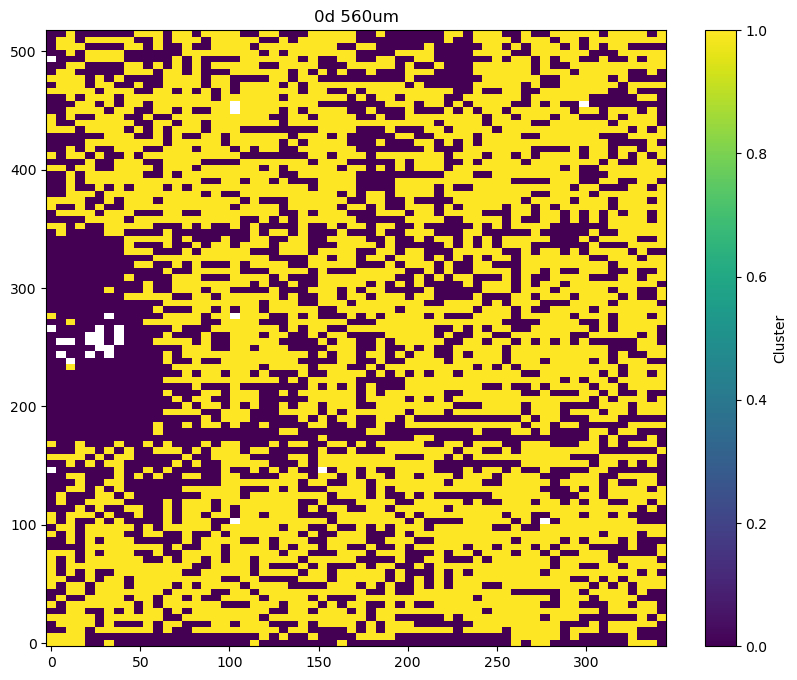

Explained variation per principal component: [0.32551372 0.19358377 0.09107323 0.07463742 0.05792982 0.03757811
 0.02568219 0.0221609  0.01599391 0.01352472]


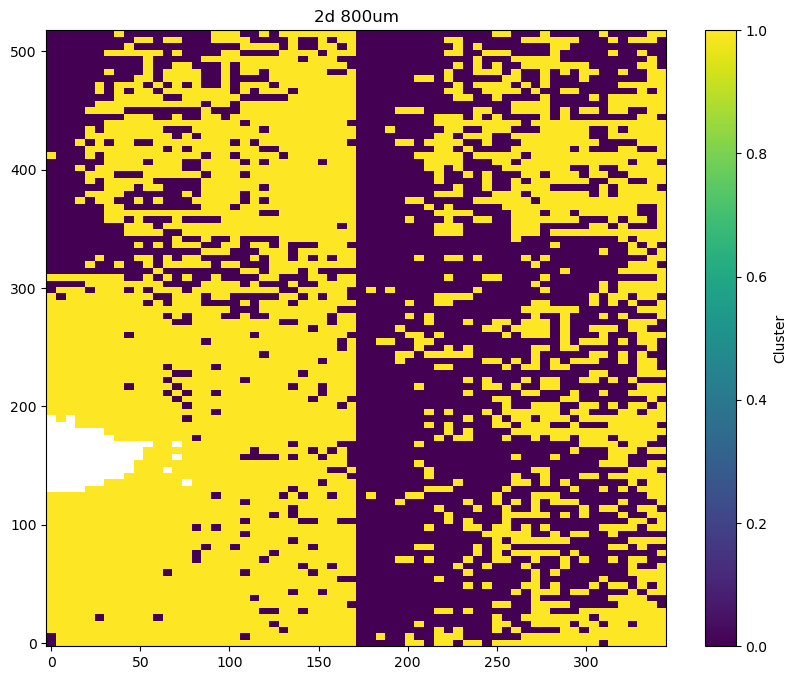

Explained variation per principal component: [0.21844616 0.19000101 0.10630851 0.08208148 0.07152402 0.04980256
 0.03149699 0.02401838 0.02168365 0.01700762]


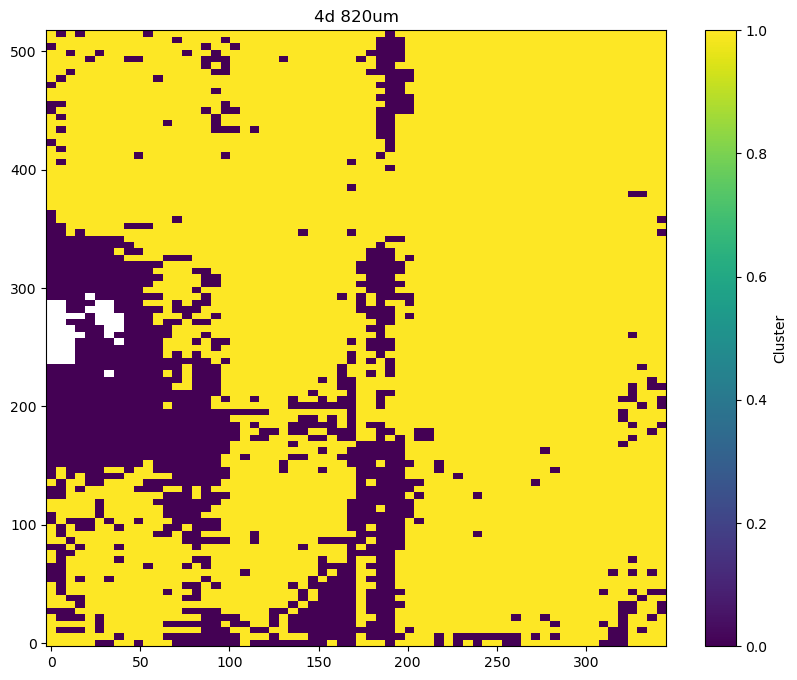

Explained variation per principal component: [0.3023238  0.1990236  0.09059389 0.08155005 0.04942621 0.03751372
 0.03188074 0.02892813 0.01797316 0.01409528]


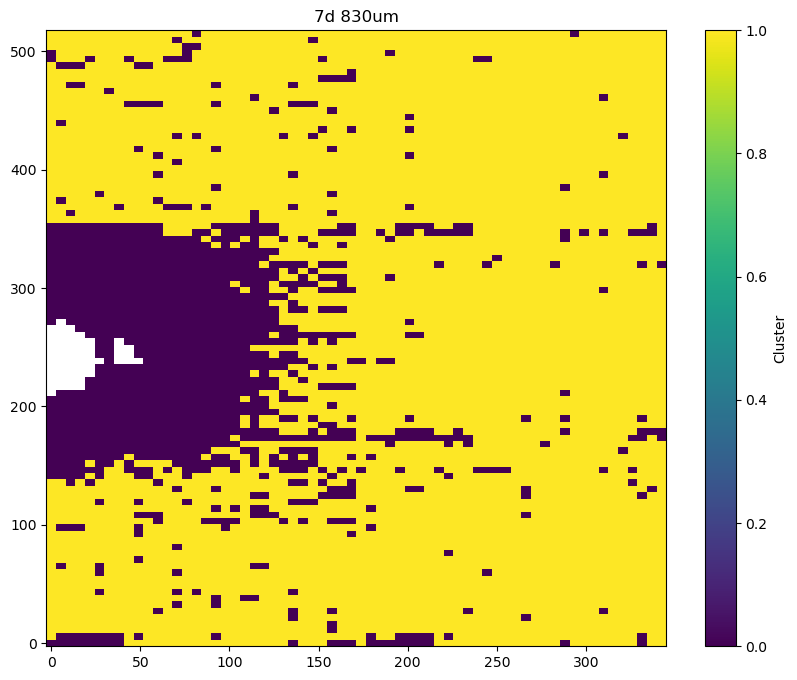

Explained variation per principal component: [0.2451381  0.22425069 0.11696231 0.08964167 0.0648356  0.03809397
 0.02674634 0.01861048 0.01788805 0.01349755]


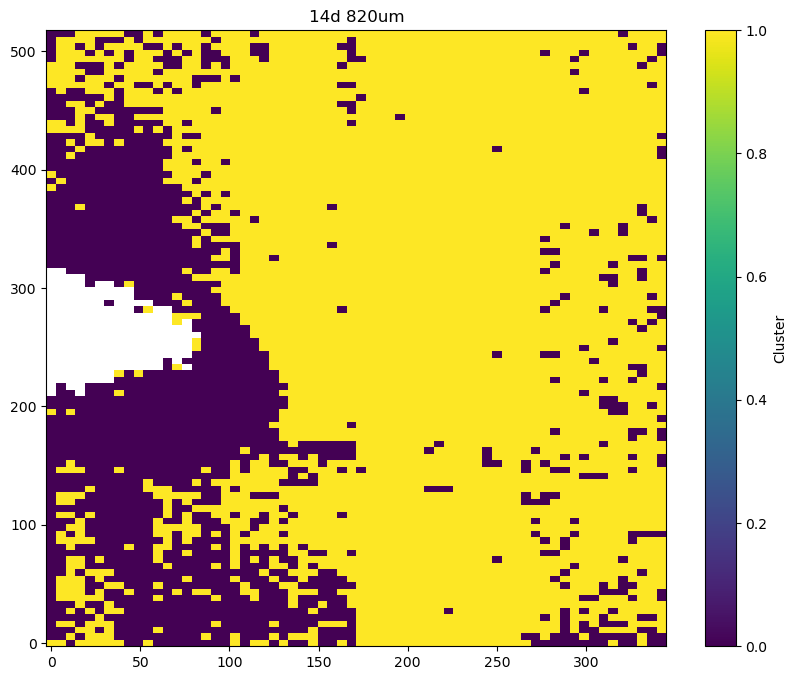

Explained variation per principal component: [0.34768794 0.12827512 0.10655207 0.08254851 0.05955624 0.03708655
 0.03172862 0.02336905 0.02085735 0.01351946]


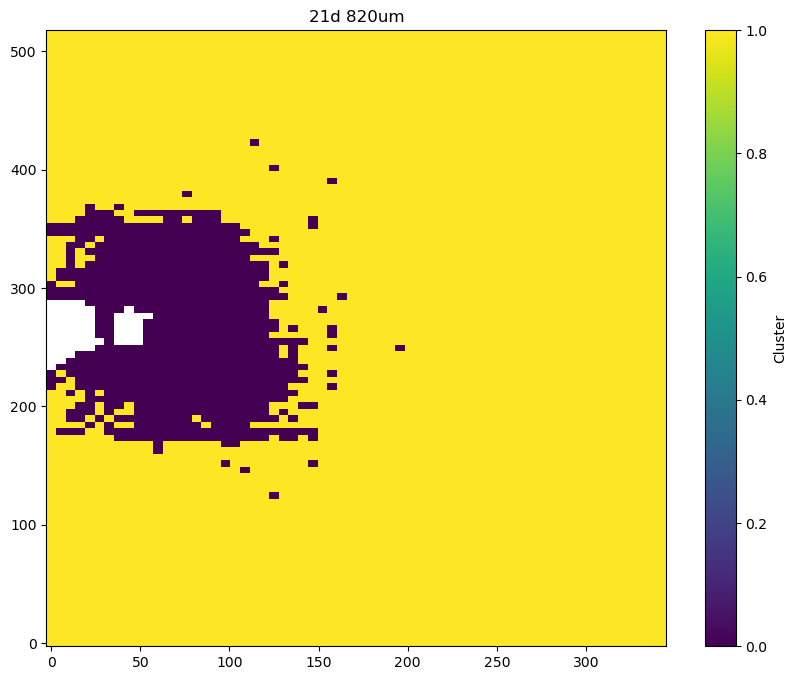

Explained variation per principal component: [0.38247573 0.14110669 0.08806853 0.06500196 0.05667494 0.02686197
 0.02201758 0.01743661 0.01540576 0.01431128]


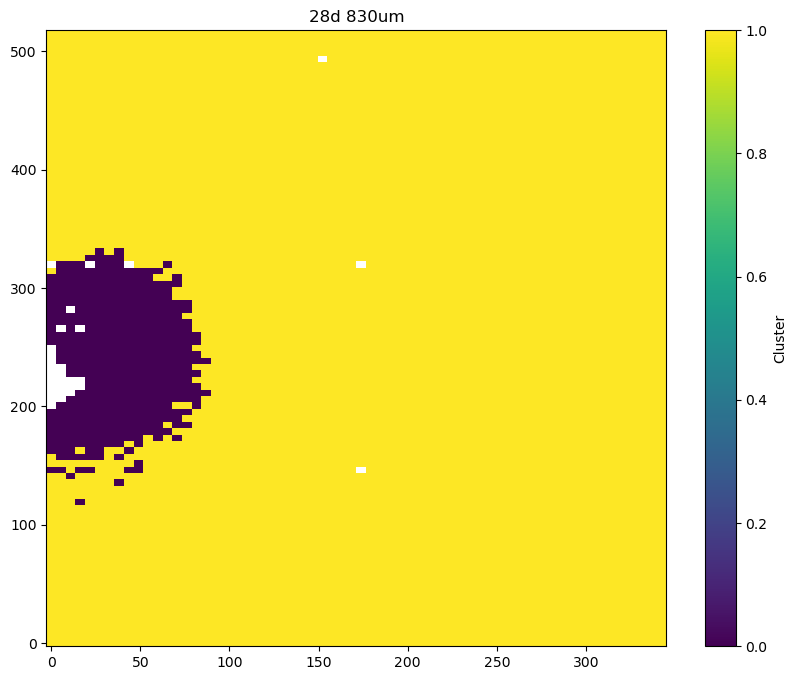

Explained variation per principal component: [0.36293188 0.16957465 0.09518614 0.07648042 0.03748715 0.02907985
 0.02512362 0.01746913 0.01555073 0.01275087]


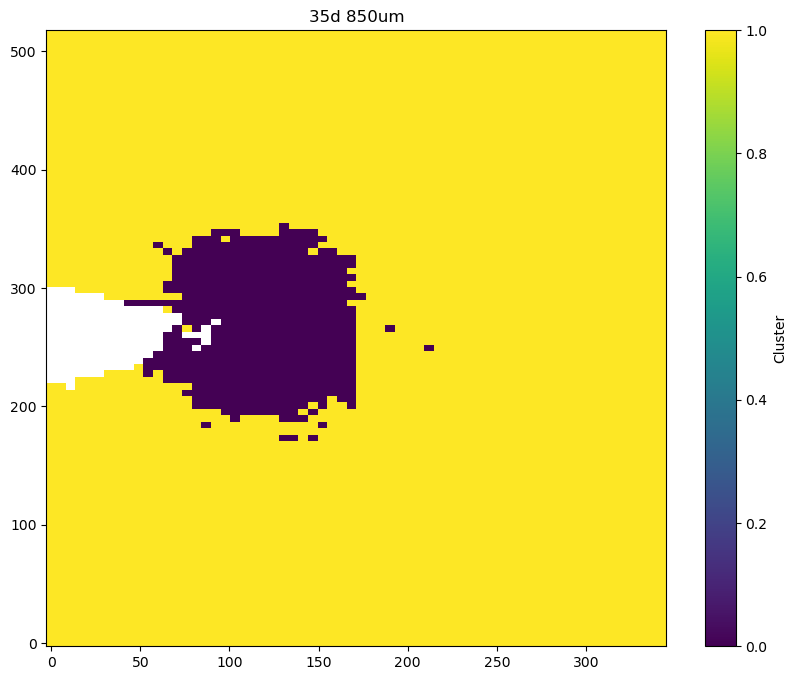

Explained variation per principal component: [0.38697824 0.14052286 0.09513966 0.06180993 0.04395614 0.03524741
 0.03020991 0.02485719 0.01693051 0.01443738]


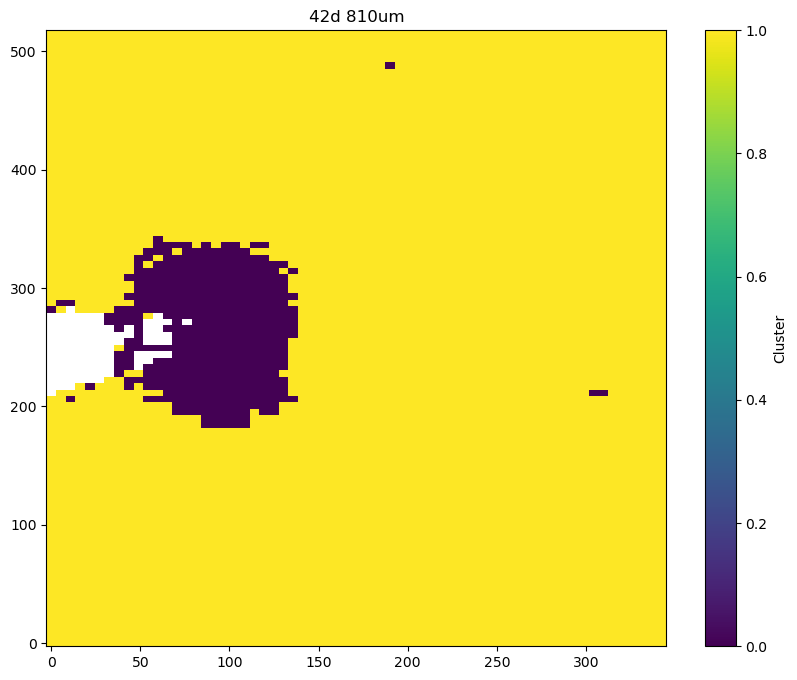

Explained variation per principal component: [0.32695961 0.22699178 0.1068004  0.0641405  0.06001783 0.02409815
 0.02074976 0.01727555 0.01362663 0.01072161]


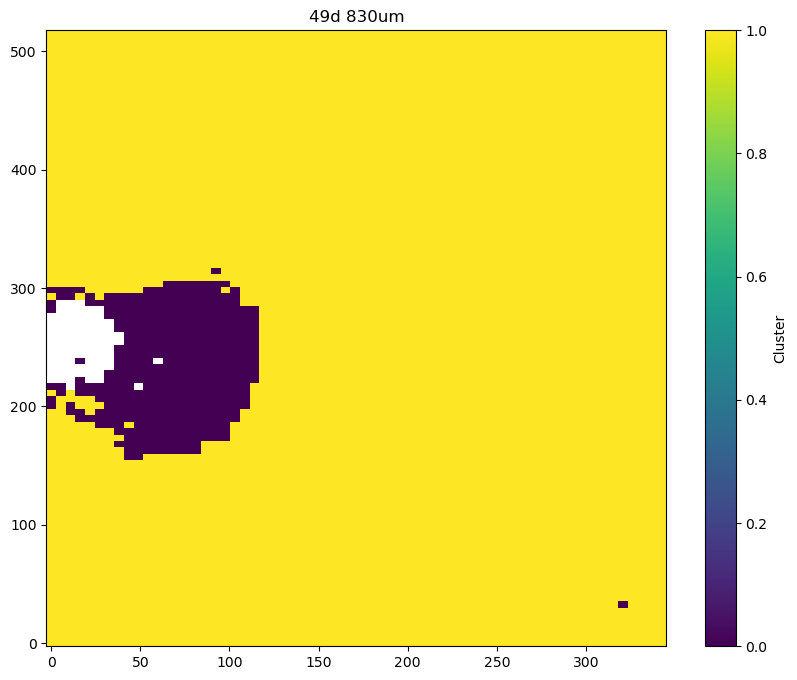

Explained variation per principal component: [0.40034655 0.12057481 0.11194442 0.08016955 0.03607046 0.03126325
 0.02835053 0.02265404 0.01368363 0.01108513]


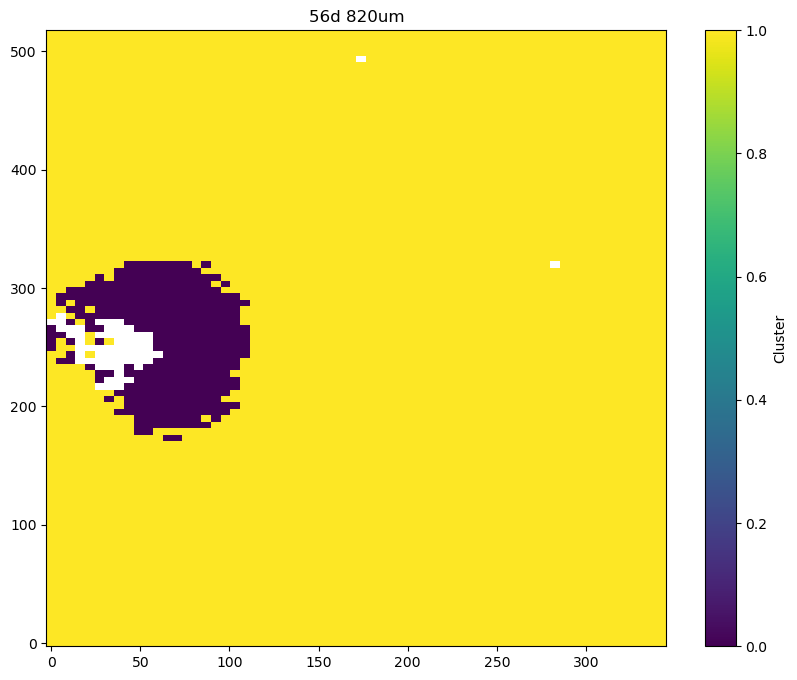

Explained variation per principal component: [0.38923367 0.15676404 0.13273786 0.09462907 0.0332385  0.02603808
 0.02384321 0.01745653 0.01127166 0.01066947]


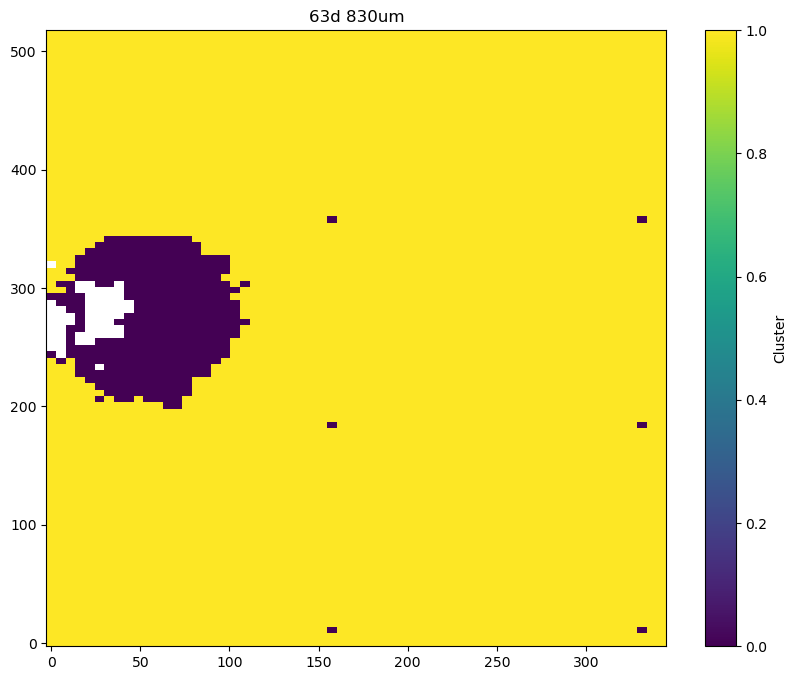

Explained variation per principal component: [0.38857509 0.17344081 0.1149659  0.09058419 0.03606405 0.02640815
 0.02274793 0.01787539 0.0113813  0.01052285]


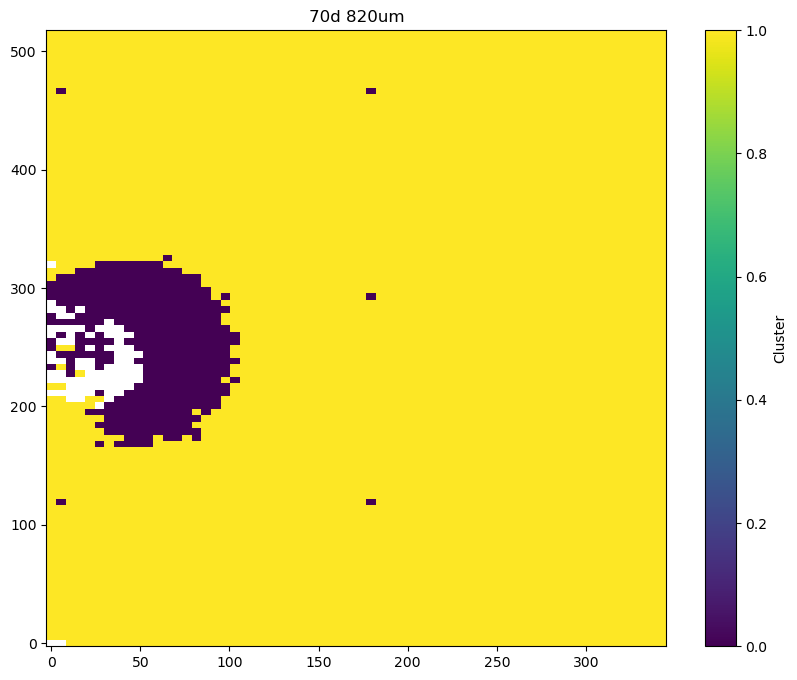

Explained variation per principal component: [0.363057   0.16710325 0.13062965 0.08192228 0.04391016 0.02644343
 0.02114344 0.01870596 0.01321342 0.01210652]


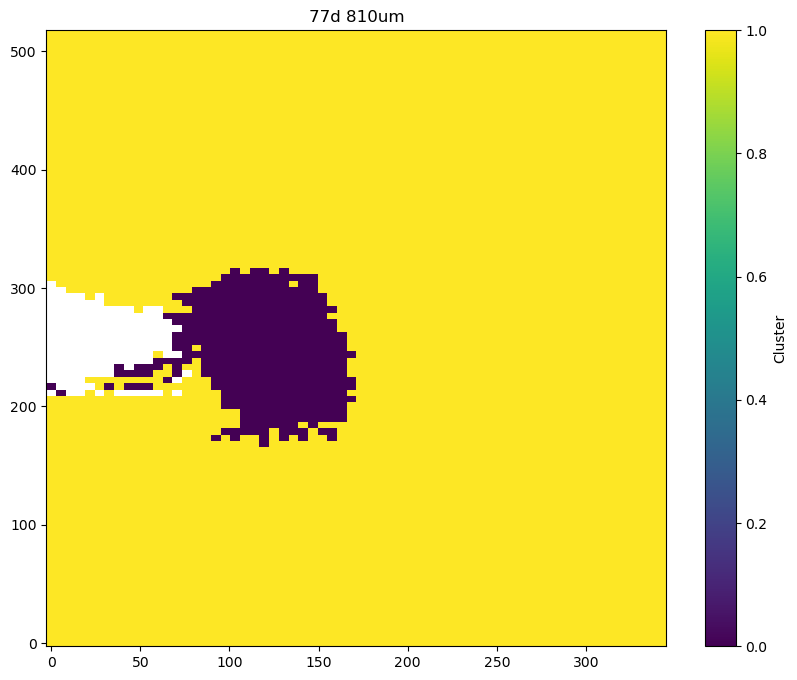

Explained variation per principal component: [0.39853632 0.14926106 0.09586755 0.09025477 0.02872637 0.02727569
 0.02272201 0.01941864 0.01678065 0.01479635]


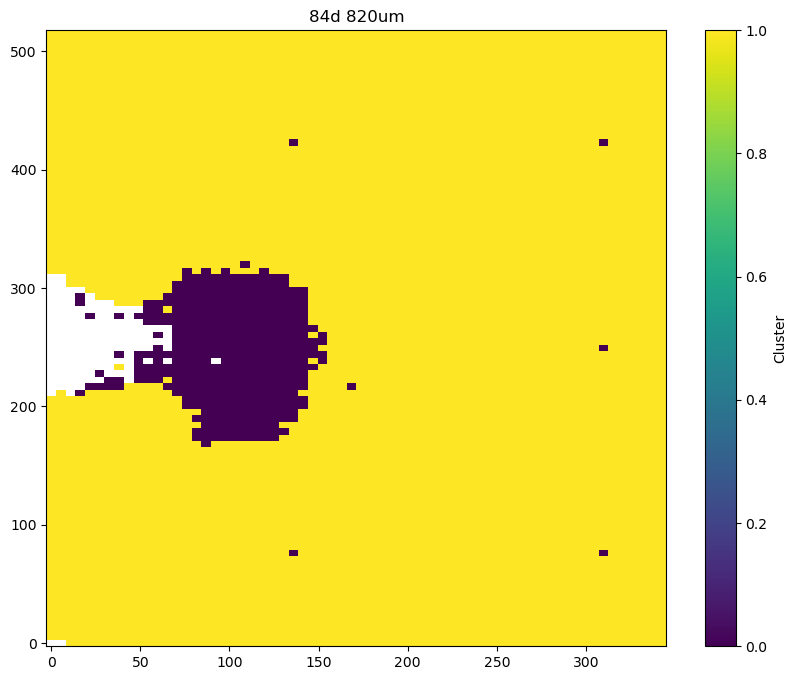

Explained variation per principal component: [0.36957733 0.13472856 0.12243968 0.0701195  0.05348826 0.03240201
 0.0232234  0.02003897 0.01330177 0.01213222]


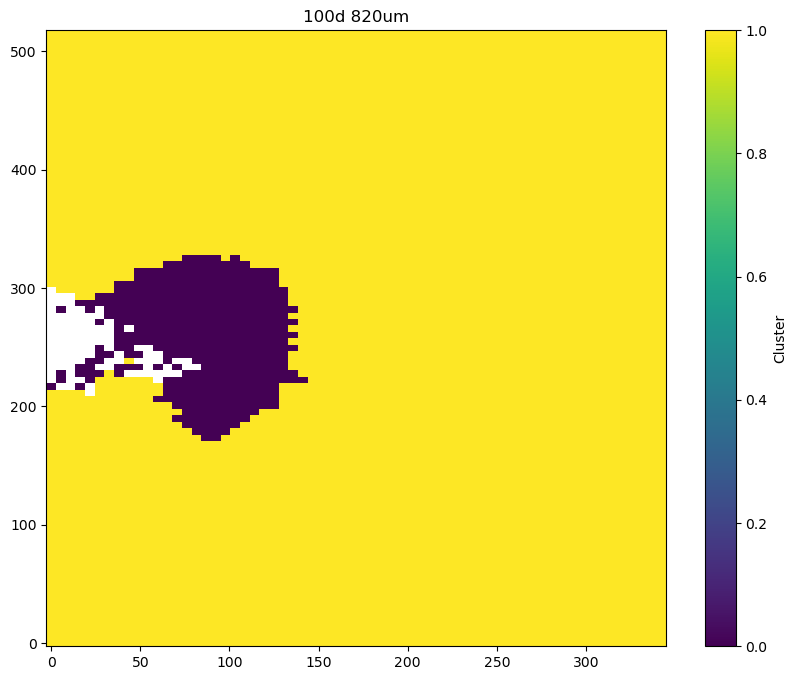

In [6]:
from sklearn.cluster import KMeans
os.environ["OMP_NUM_THREADS"] = "2" # Defining number of threads to avoid memory leak in Kmeans on Windows
from sklearn.metrics import silhouette_score

list_of_labels = {}
for key in keys:
    training_df = dfs[key]
    #Reposition the mapping to start at 0,0 
    Map_x = training_df['map_x'].to_numpy()
    Map_y = training_df['map_y'].to_numpy()
    Map_y2 = []
    Map_x2 = []
    Min_x = min(Map_x)
    Min_y = min(Map_y)

    Map_x2 = Map_x - Min_x
    Map_y2 = Map_y - Min_y

    training_df.loc[:, 'map_x'] = Map_x2
    training_df.loc[:, 'map_y'] = Map_y2

    x_unique = np.sort(training_df["map_x"].unique())
    y_unique = np.sort(training_df["map_y"].unique())

    X, Y = np.meshgrid(x_unique, y_unique)

    PCs=10

    PC_inputData = training_df[wavenumbers].copy()

    PCA_output = IR_PCA(PC_inputData, PCs)

    PC_df = PCA_output[0]
    loadings_df = PCA_output[1]

    kmeans = KMeans(n_clusters=2, random_state=42).fit(PC_df.values)
    labels = kmeans.fit_predict(PC_df)
    # Arange the clusters by the consumption level, or the amount of data points the cluster contains
    cluster_sizes = np.bincount(labels)
    idx = np.argsort(cluster_sizes)
    lut = np.zeros_like(idx)
    lut[idx] = np.arange(2)

    training_df = training_df.copy()
    training_df["cluster"] = lut[labels]
    dfs[key] = training_df

    Z = (training_df.pivot(index="map_y", columns="map_x", values="cluster").sort_index(ascending=True).values)

    plt.figure(figsize=(10, 8))

    plt.pcolormesh(X, Y, Z, shading="auto", cmap="viridis")

    plt.xlabel("")
    plt.ylabel("")
    plt.title(f'{key}')
    plt.colorbar(label="Cluster")

    plt.show()

Plot Average Spectra of Clusters

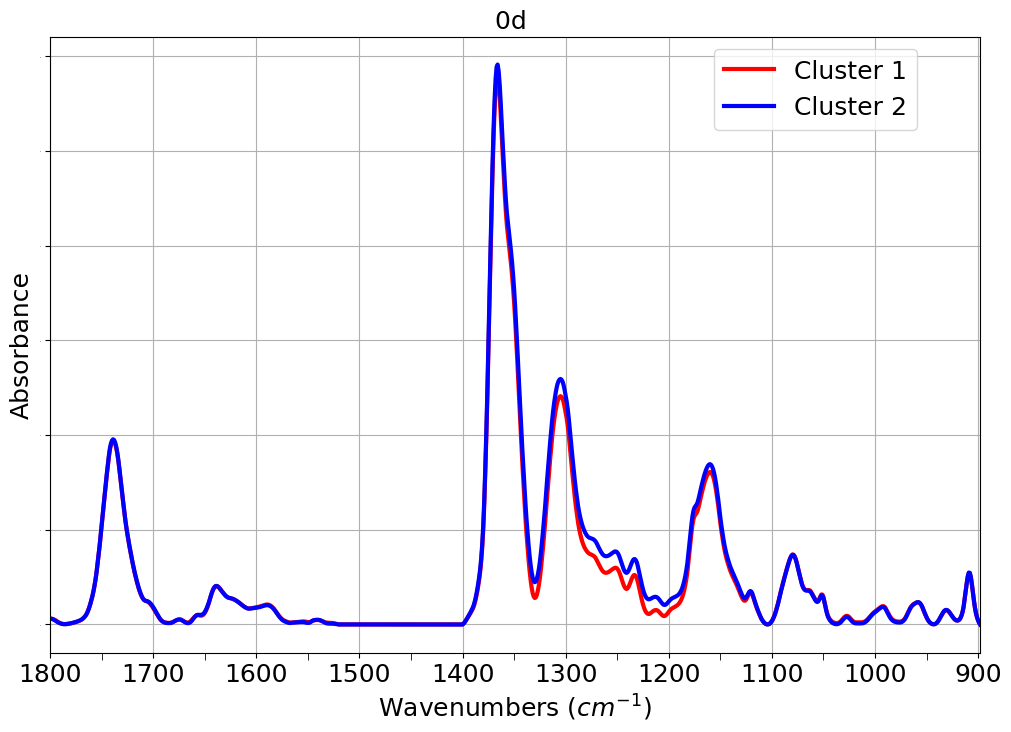

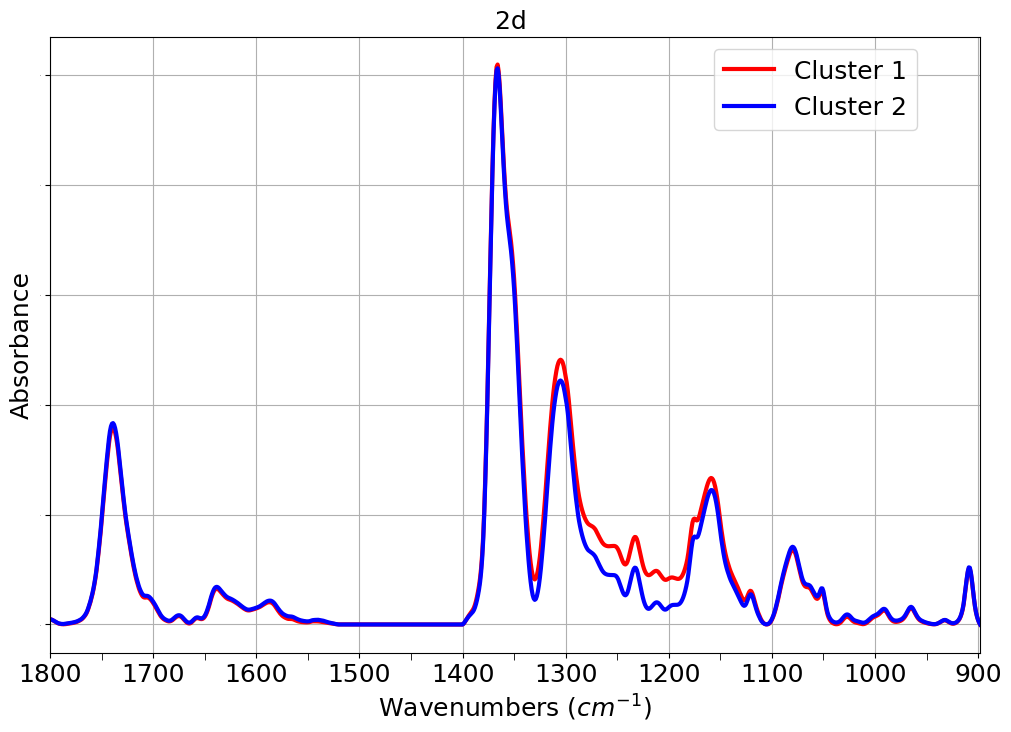

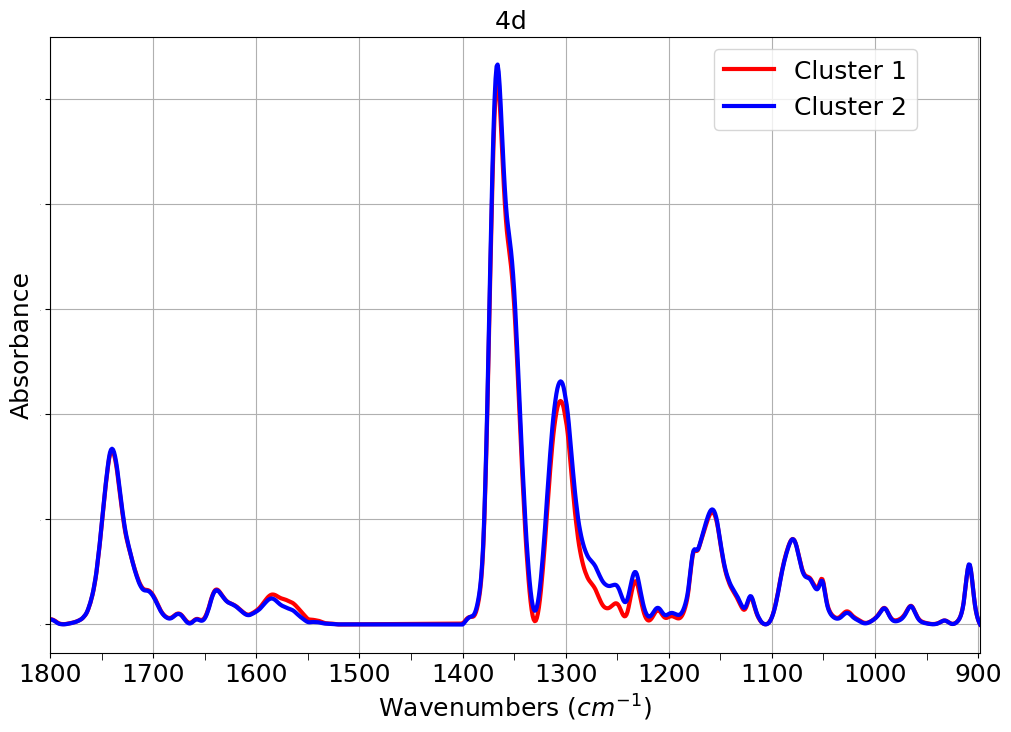

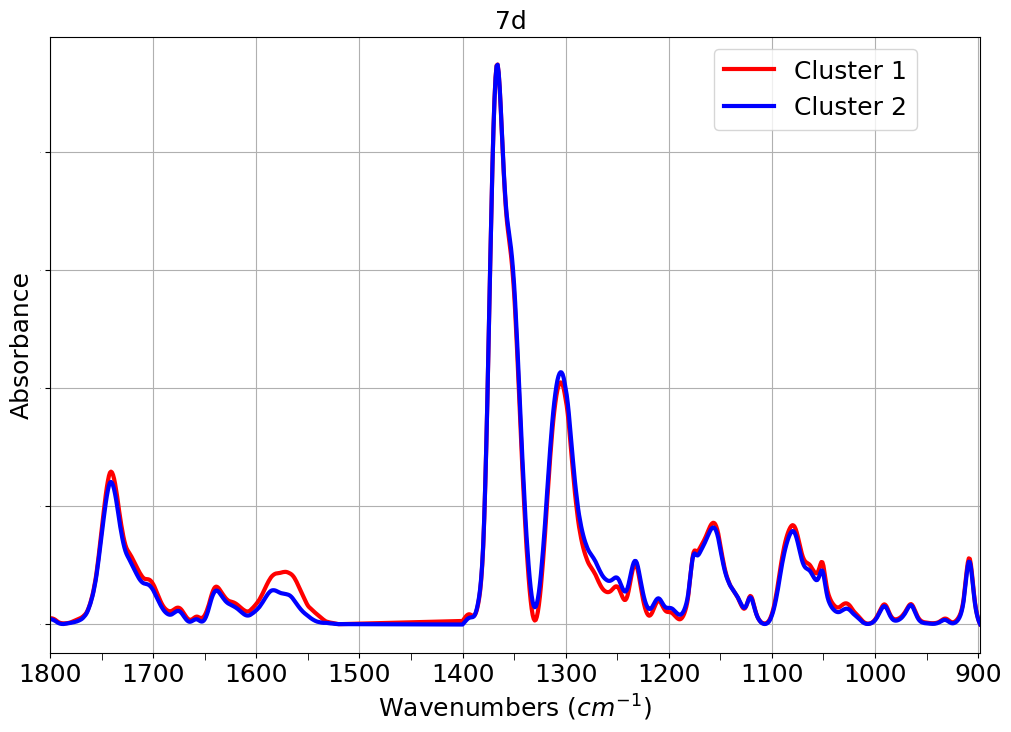

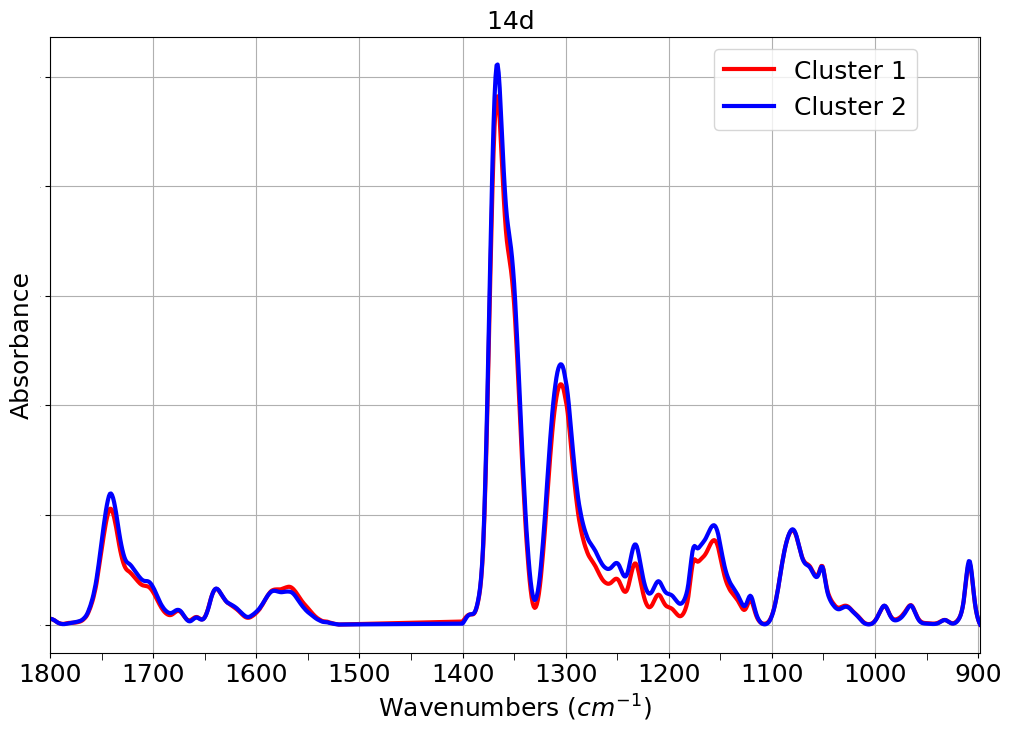

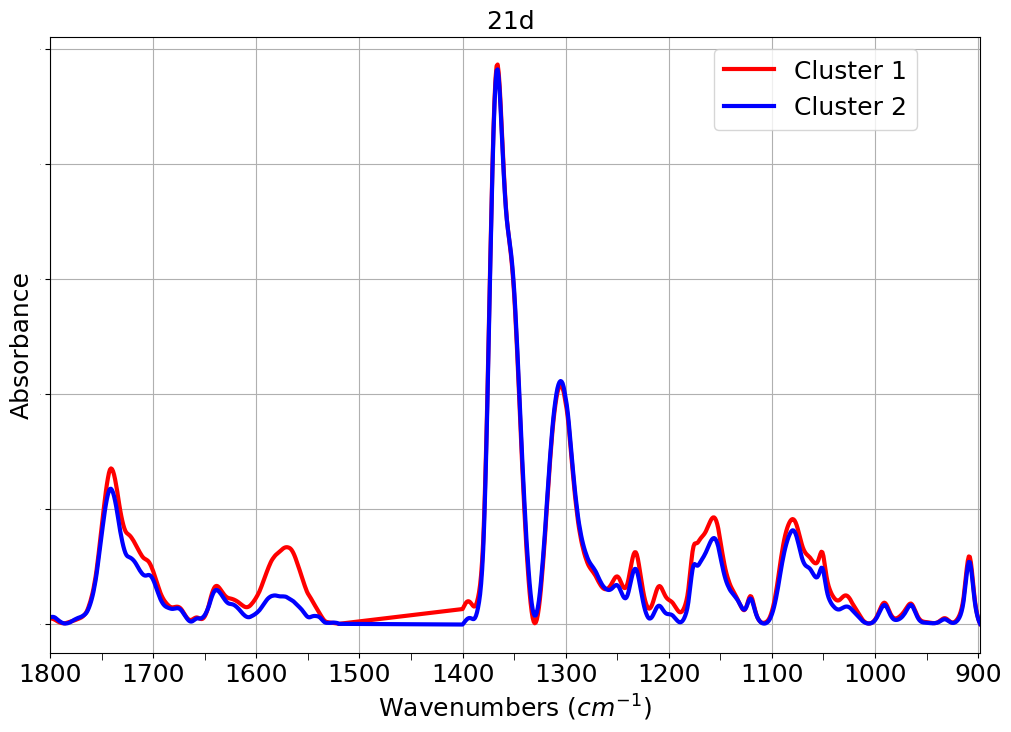

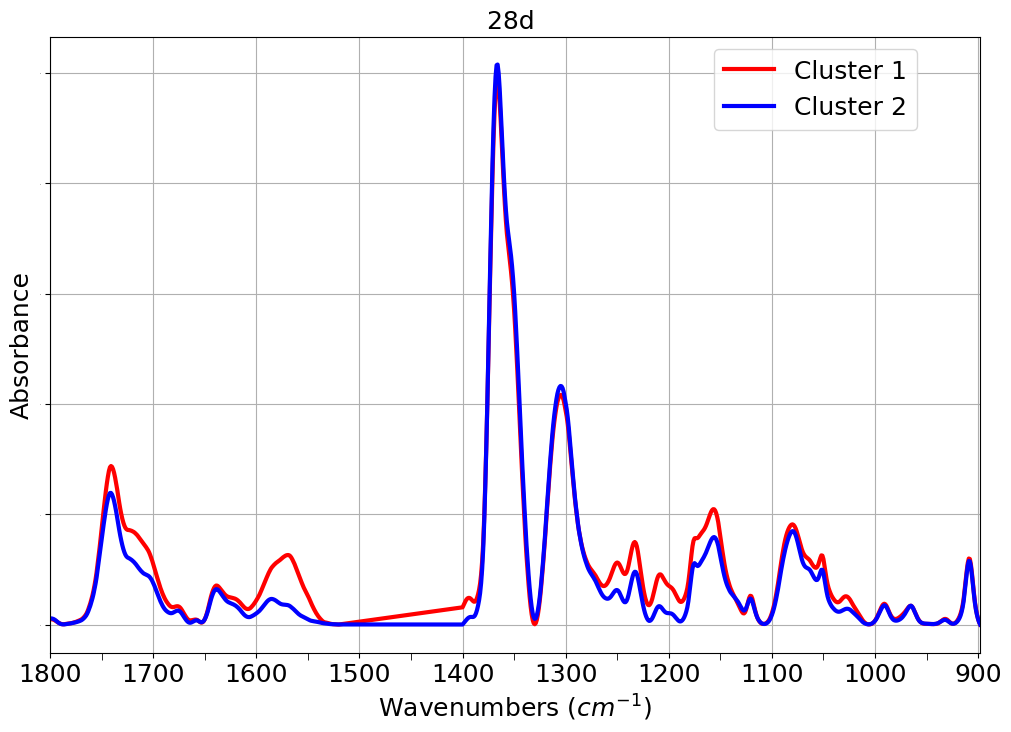

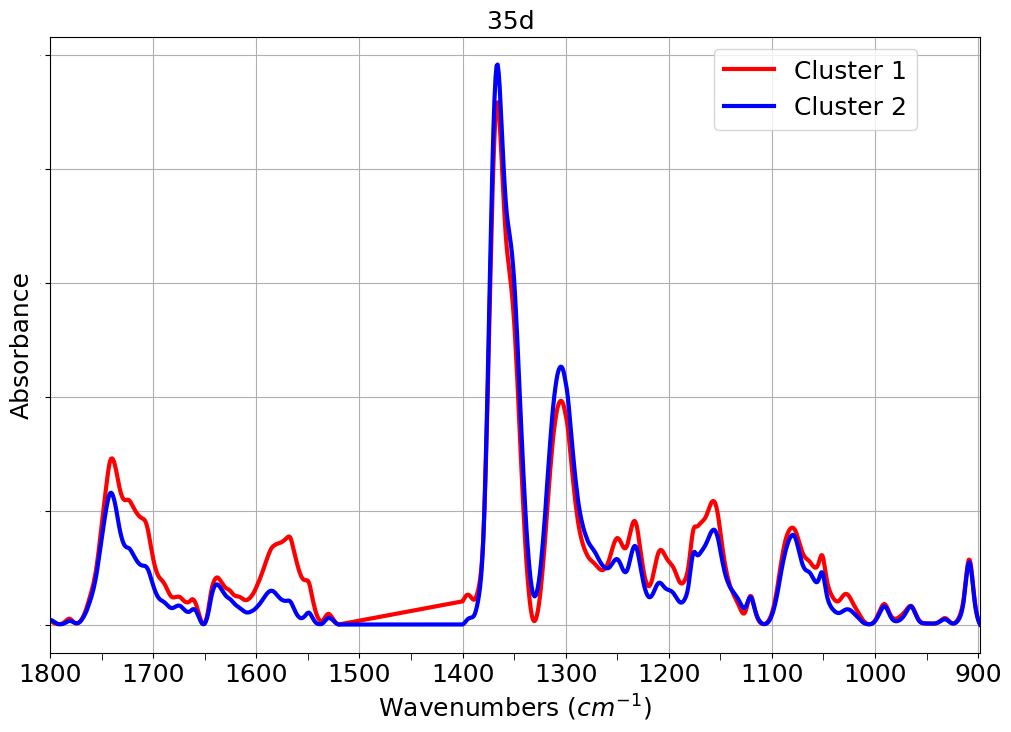

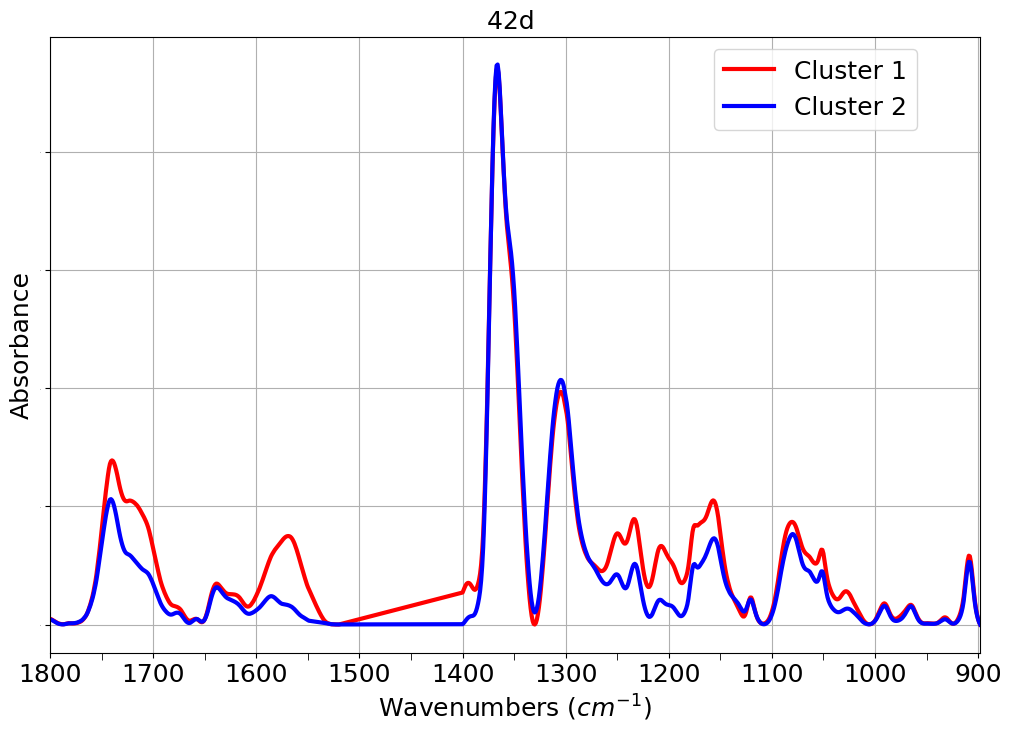

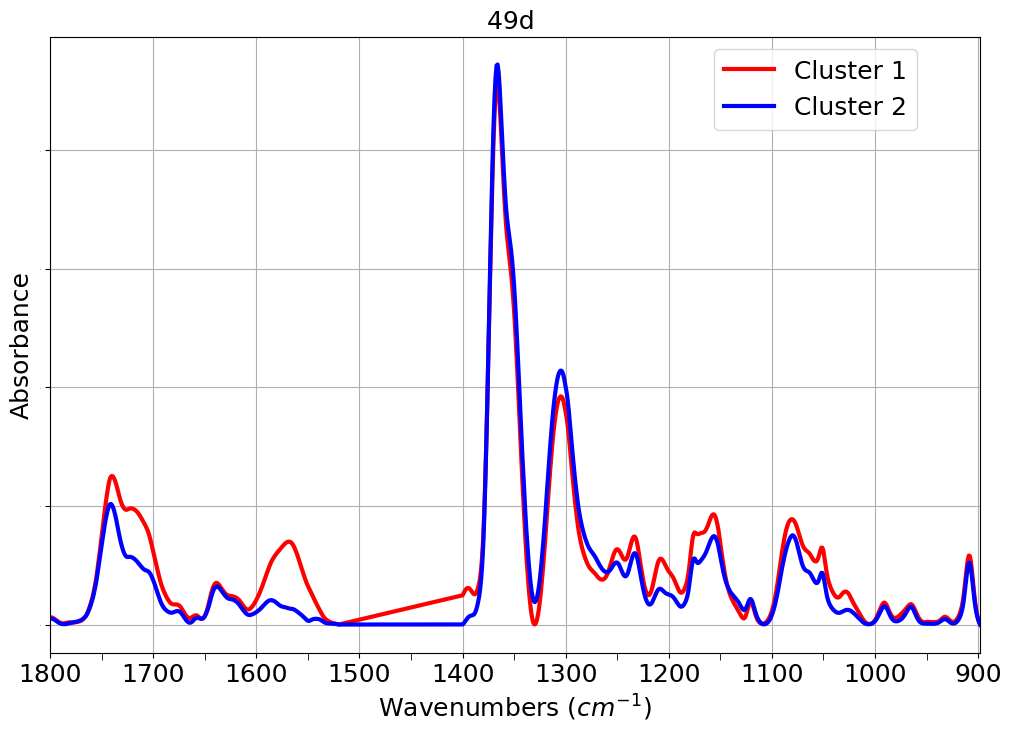

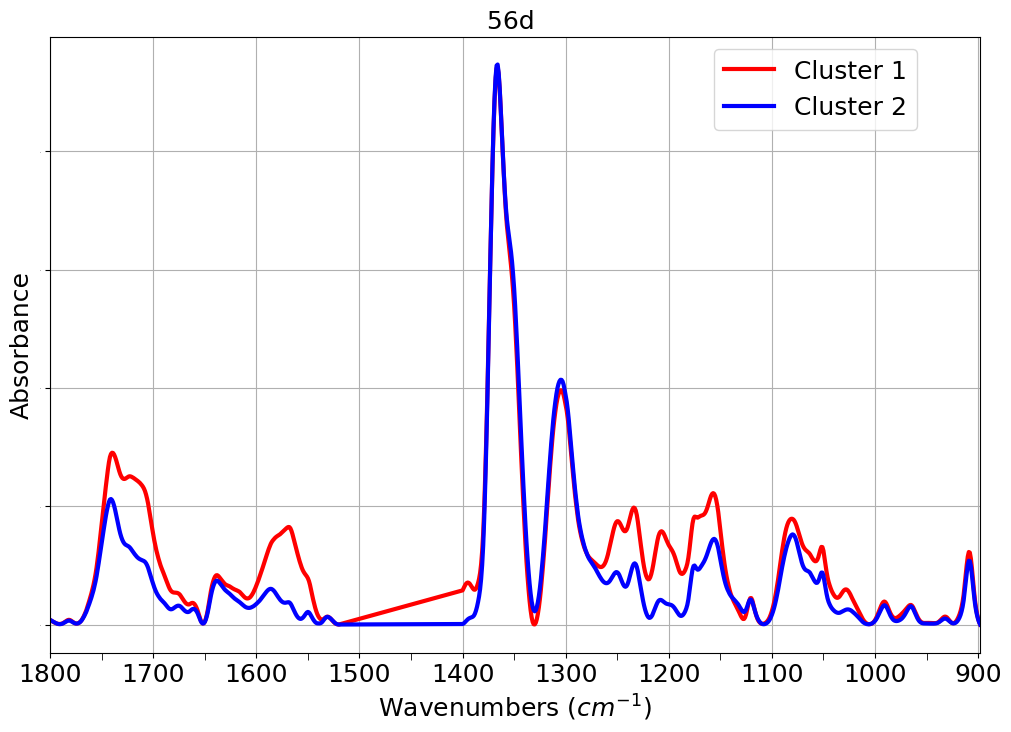

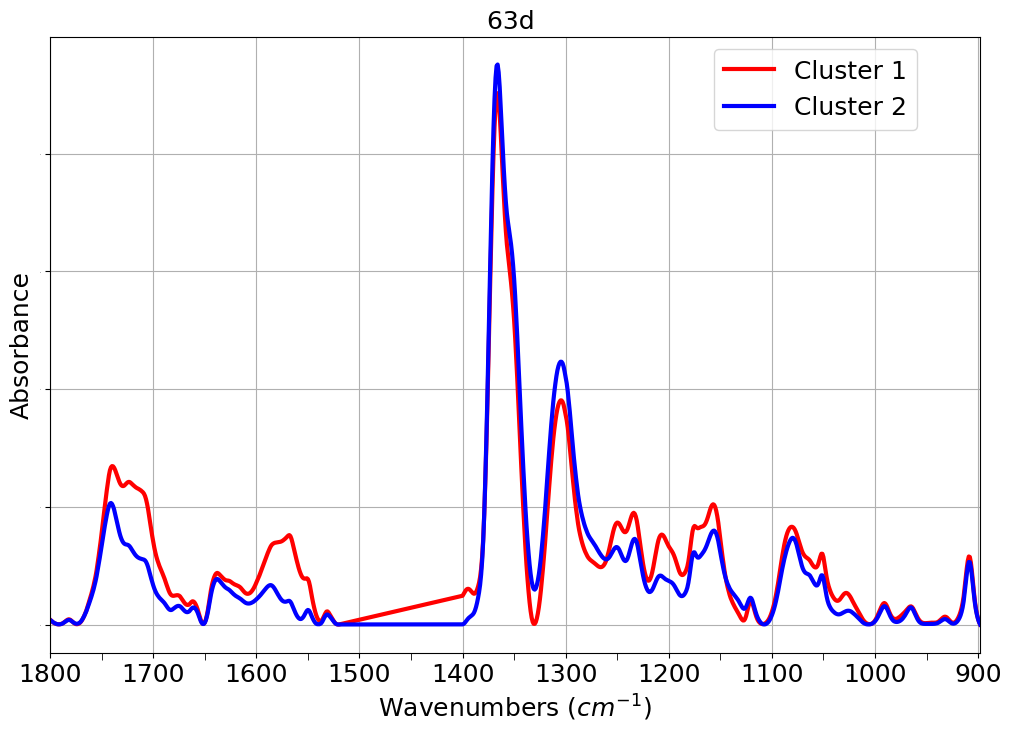

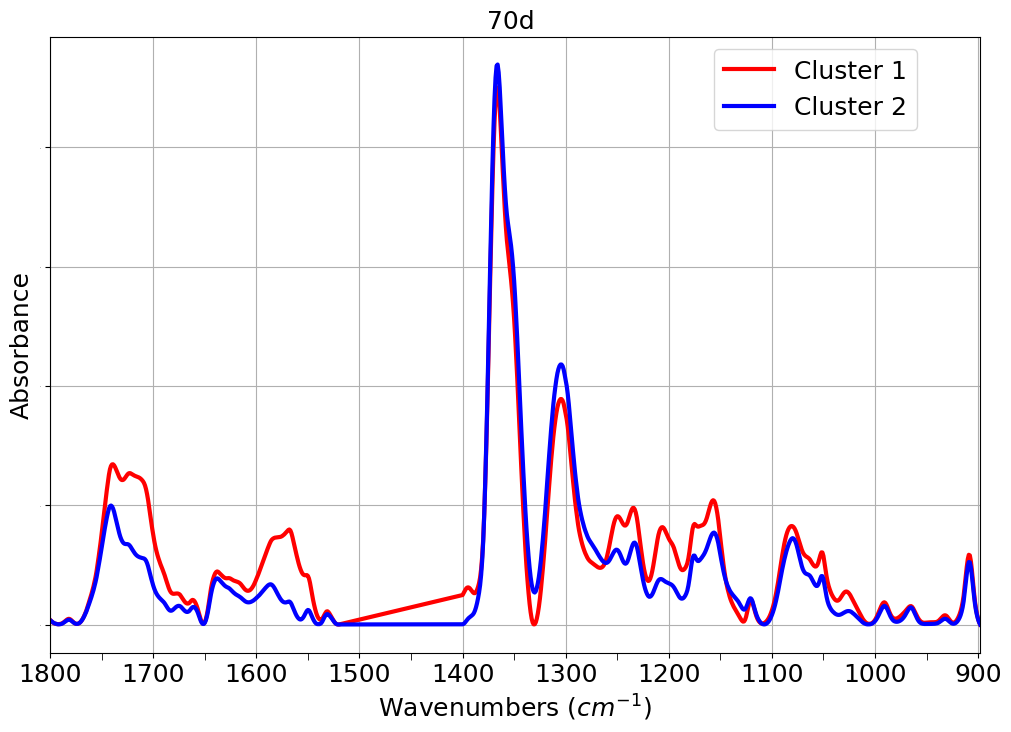

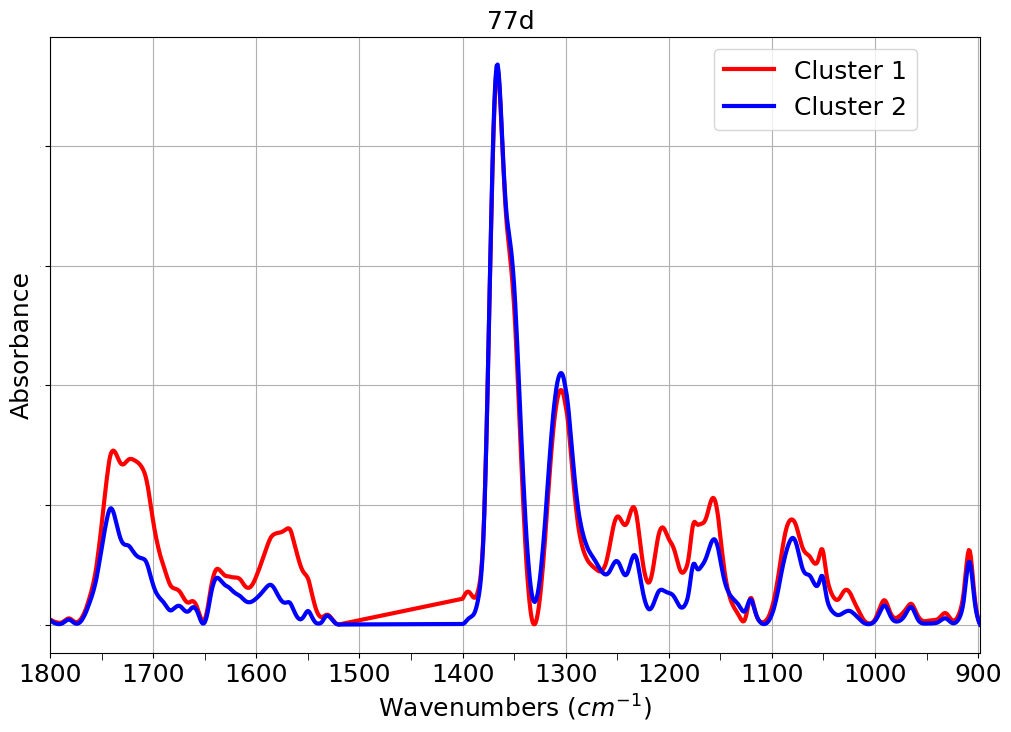

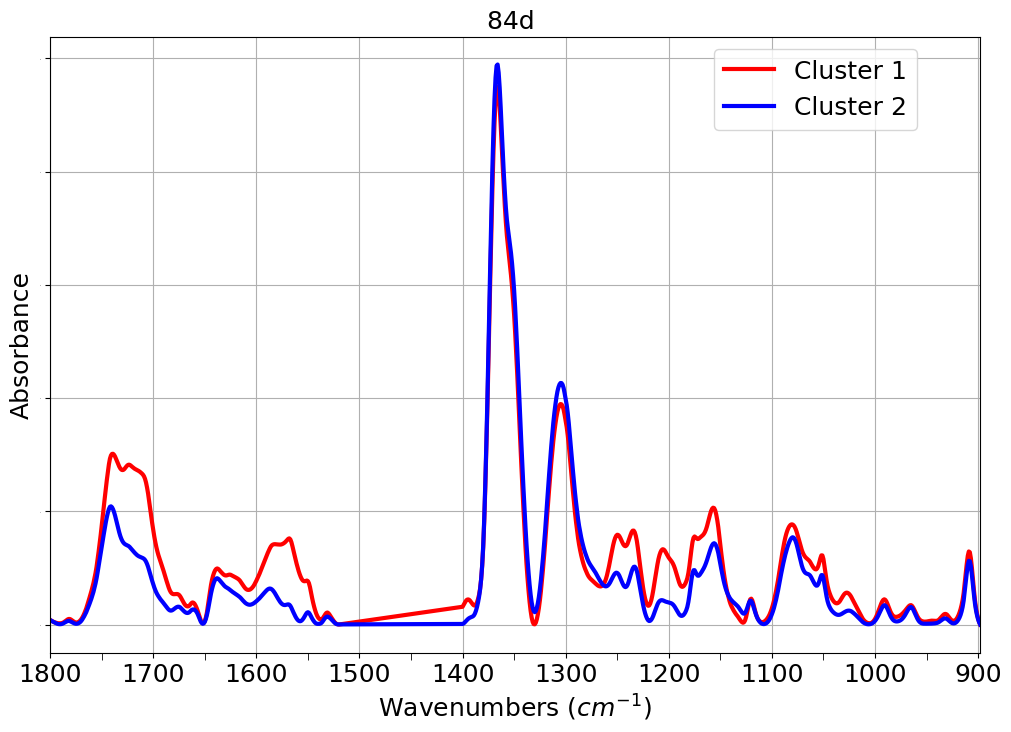

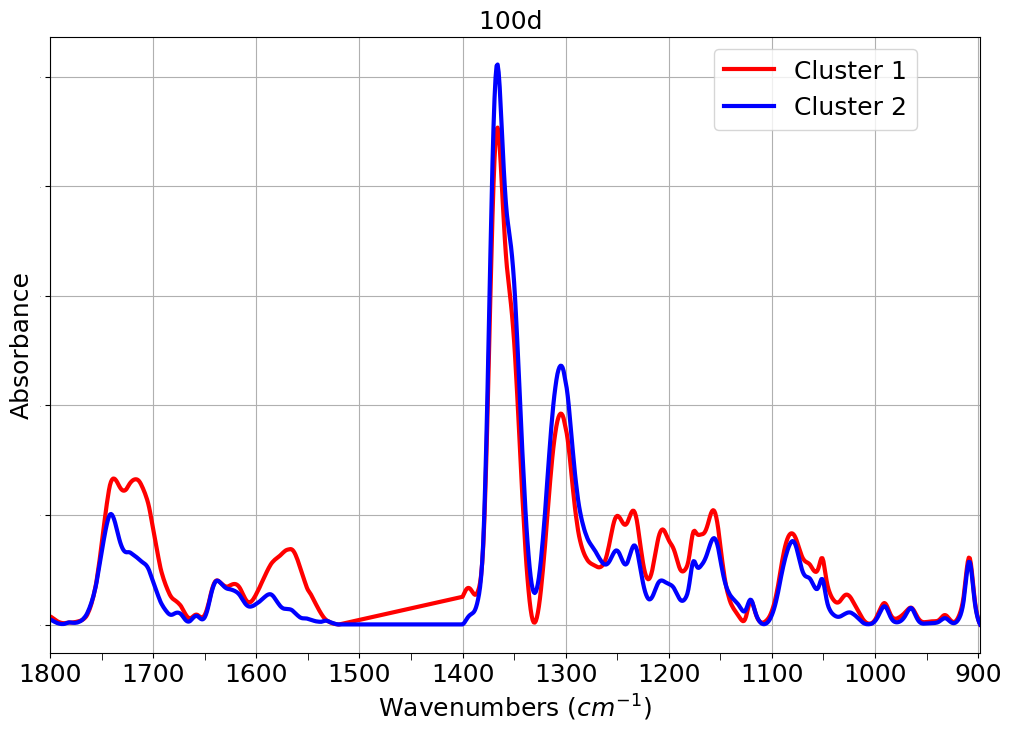

In [7]:
cluster1_spectra = []
cluster2_spectra = []

for key in keys: 
    training_df = dfs[key]

    clustered_df = training_df.groupby('cluster').mean(numeric_only=True)

    clustered_spectra = clustered_df[wavenumbers]
    frequencies = wavenumbers.astype(float)

    cluster1_spectra.append(clustered_spectra.values[0].astype(float))
    cluster2_spectra.append(clustered_spectra.values[1].astype(float))

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_ylabel('Absorbance', fontsize=18)
    ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
    ax.set_title(key[:-5], fontsize=18)
    ax.plot(frequencies, clustered_spectra.values[0].astype(float), color='r', linewidth=3)
    ax.plot(frequencies, clustered_spectra.values[1].astype(float), color='b', linewidth=3)
    
    ax.tick_params(which='major', axis='x', labelsize=18)
    ax.tick_params(which='minor', axis='x', length=5)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.legend(labels=['Cluster 1', 'Cluster 2'],
            fontsize=18, loc='upper left', 
            bbox_to_anchor=(0.7, 0.5, 0.5, 0.5))
    ax.tick_params(axis='y', labelsize=0)

    ax.set_xlim(frequencies[-1], frequencies[0])
    ax.grid(True)

Plotting the spectra of each Cluster as a Function of Time

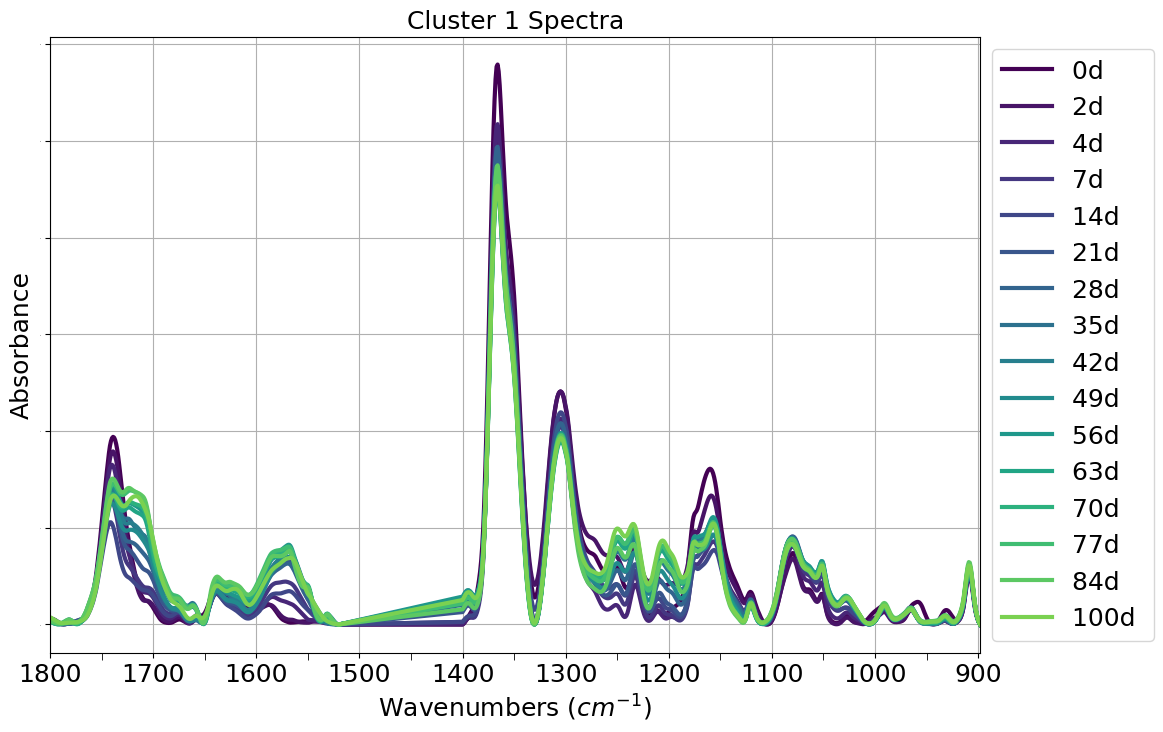

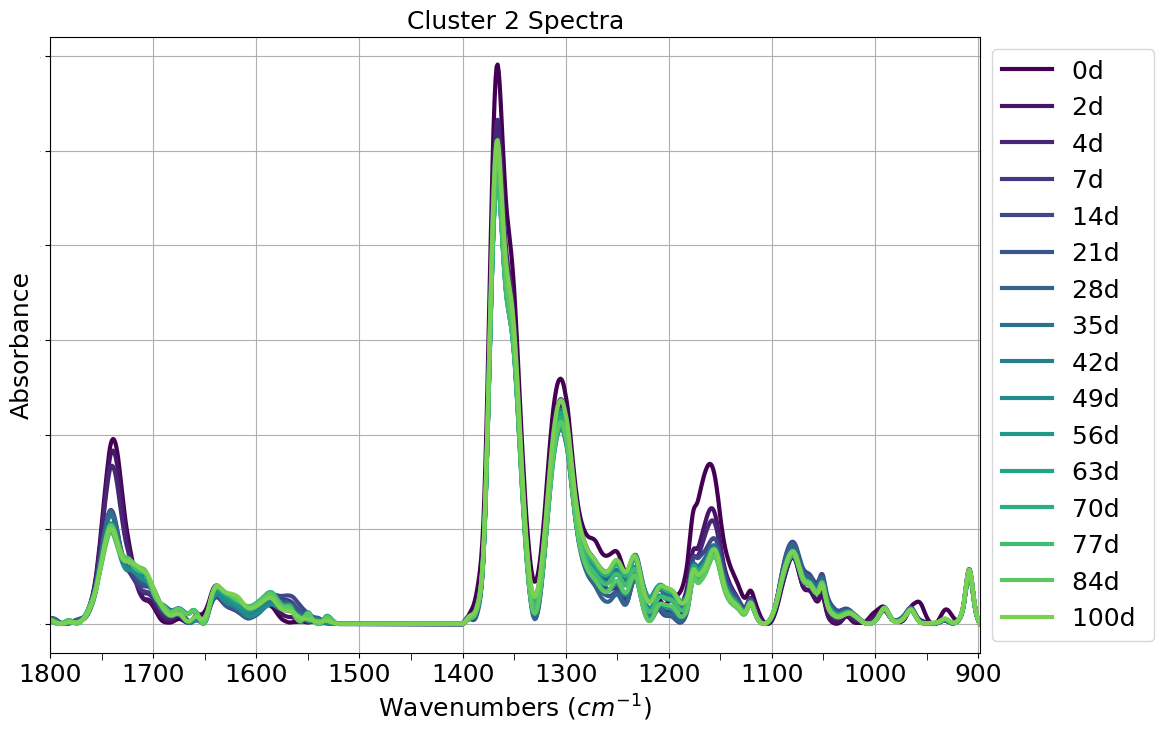

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(cluster1_spectra)))

ax.set_ylabel('Absorbance', fontsize=18)
ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
ax.set_title("Cluster 1 Spectra", fontsize=18)

for i in range(len(cluster1_spectra)):
        ax.plot(frequencies, cluster1_spectra[i], color=colors[i], linewidth=3)

ax.tick_params(which='major', axis='x', labelsize=18)
ax.tick_params(which='minor', axis='x', length=5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.legend(labels=[key[:-5] for key in keys],
        fontsize=18, loc='upper right', 
        bbox_to_anchor=(0.7, 0.5, 0.5, 0.5))
ax.tick_params(axis='y', labelsize=0)

ax.set_xlim(frequencies[-1], frequencies[0])
ax.grid(True)


fig, ax = plt.subplots(figsize=(12, 8))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(cluster2_spectra)))

ax.set_ylabel('Absorbance', fontsize=18)
ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
ax.set_title("Cluster 2 Spectra", fontsize=18)

for i in range(len(cluster2_spectra)):
        ax.plot(frequencies, cluster2_spectra[i], color=colors[i], linewidth=3)

ax.tick_params(which='major', axis='x', labelsize=18)
ax.tick_params(which='minor', axis='x', length=5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.legend(labels=[key[:-5] for key in keys],
        fontsize=18, loc='upper right', 
        bbox_to_anchor=(0.7, 0.5, 0.5, 0.5))
ax.tick_params(axis='y', labelsize=0)

ax.set_xlim(frequencies[-1], frequencies[0])
ax.grid(True)    